# Analysis of Utilized Model Capacity — Local Effective Dimension with the **Gaussian (MSE-consistent) Fisher**

This notebook computes the Local Effective Dimension (LED) of Abbas et al. (2021, [arXiv:2011.00027](https://arxiv.org/abs/2011.00027); 2112.04807) for the trained VQC weights $\theta^\star$, using a Fisher Information Matrix (FIM) that is **strictly consistent with the loss the models were actually trained under**.

LED estimates the number of parameter directions the converged solution $\theta^\star$ actually exploits, *locally* at $\theta^\star$:
$$d_{\gamma,n}(\theta^\star)=\frac{\log\det\!\big(I_d+\kappa\,\hat F(\theta^\star)\big)}{\log\kappa},\qquad \kappa=\frac{\gamma n}{2\pi\log n}.$$

### The Gaussian Fisher

The VQCs in this project were trained with **`torch.nn.MSELoss`** on the raw expectation value $\langle Z\rangle\in[-1,1]$ against targets $y\in\{-1,+1\}$. MSE is the negative log-likelihood of a **homoscedastic Gaussian observation model** $y\mid x\sim\mathcal N\big(\langle Z\rangle_\theta(x),\,\sigma^2\big)$, whose Fisher information is

$$
F_{\mathrm G}(\theta)=\frac{1}{\sigma^2}\,\mathbb{E}_x\big[g\,g^{\!\top}\big],\qquad g=\nabla_\theta\langle Z\rangle\quad(\text{raw output Jacobian}).
$$

Qiskit's `EstimatorQNN`/`LocalEffectiveDimension` instead build the **categorical** Fisher of a Bernoulli readout $p_\pm=(1\pm\langle Z\rangle)/2$, i.e. $F_{\mathrm C}=\mathbb{E}_x\big[g\,g^{\!\top}/(1-\langle Z\rangle^2)\big]$. The per-sample weight $1/(1-\langle Z\rangle^2)$ **diverges for saturated samples** ($\langle Z\rangle\to\pm1$) — exactly the points MSE training drives to *zero* gradient influence.

### Methodology

For every weight file `fold_F/...epoch_30_weights.pth`:

* Load fold F's own training CSV and draw a deterministic, glob-order-independent subsample of `k = 200` inputs (per-fold seed `42 + F`; the same inputs are reused by every depth/environment on that fold).
* Get the raw Jacobian $g_j=\nabla_\theta\langle Z\rangle(x_j)$ from `qnn.backward` (exact parameter-shift on a noise-free `StatevectorEstimator`) and form the **unweighted** empirical Fisher
  $$\hat F(\theta^\star)=\frac{1}{k}\sum_{j=1}^{k} g_j g_j^{\!\top}.$$
* **Trace-normalize** to $\operatorname{tr}=d$ (Abbas convention). The unknown noise scale $\sigma^2$ is a global constant that this normalization removes — so it never has to be estimated.
* Add a small ridge $\hat F\leftarrow\hat F+\varepsilon I$ ($\varepsilon=10^{-8}$) to stabilize `slogdet` on rank-deficient folds, and compute LED at $\gamma=1$ with $n=$ the fold's true training size (1097/1098).

We also record, per model, $\max_j|\langle Z\rangle(x_j)|$ and the saturated-sample fraction, so the impact of the Gaussian-vs-categorical choice is visible and quantifiable.

Reported numbers are **mean ± std across the 5 folds** per (environment, depth). The cross-fold std is a *descriptive* fold-to-fold spread, **not** a valid standard error: the 5 CV training sets overlap ~80 %, so the folds are statistically dependent.

### Scope of the noise comparison

Both `*_epoch_30_weights.pth` and `*_noise_epoch_30_weights.pth` are loaded, but the FIM is always computed with a noise-free `StatevectorEstimator`. The "Noise" column distinguishes **where the trained weights came from** (training under a noise model vs. ideal), not the channel used to evaluate LED — isolating the effect of noise on the converged solution from its effect on the live model.

In [17]:
import os
import glob
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.primitives import StatevectorEstimator
from qiskit.quantum_info import SparsePauliOp
from qiskit_machine_learning.connectors import TorchConnector
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_algorithms.gradients import ParamShiftEstimatorGradient

np.random.seed(42)
torch.manual_seed(42)

In [2]:
def ansatz_trimmed_reverse_q0_param_count(n_qubits: int, depth: int) -> int:
    m = depth // 2
    if m == 0:
        return 0
    full = 4 * n_qubits
    last = 3 * n_qubits + 2
    return (m - 1) * full + last

def odra_ansatz(n_qubits: int, depth: int) -> QuantumCircuit:
    n_macro = depth // 2
    theta = ParameterVector("theta", ansatz_trimmed_reverse_q0_param_count(n_qubits, depth))
    qc = QuantumCircuit(n_qubits)
    p = 0

    for j in range(n_macro):
        last_layer = j == n_macro - 1
        for i in range(n_qubits):
            qc.ry(theta[p + i], i)
        p += n_qubits
        for i in range(n_qubits):
            control = i
            target = (i + 1) % n_qubits
            qc.rz(theta[p + i], target)
            qc.cz(control, target)
        p += n_qubits
        for i in range(n_qubits):
            qc.rx(theta[p + i], i)
        p += n_qubits
        if last_layer:
            for k in range(2):
                i = k
                control = i
                target = (i - 1) % n_qubits
                qc.ry(theta[p + k], target)
                qc.cz(control, target)
            p += 2
        else:
            for i in range(n_qubits):
                control = i
                target = (i - 1) % n_qubits
                qc.ry(theta[p + i], target)
                qc.cz(control, target)
            p += n_qubits
    return qc

def simulator_ansatz(n_qubits: int, depth: int) -> QuantumCircuit:
    n_macro = depth // 2
    theta = ParameterVector("theta", ansatz_trimmed_reverse_q0_param_count(n_qubits, depth))
    qc = QuantumCircuit(n_qubits)
    param_idx = 0

    for j in range(n_macro):
        last_layer = j == n_macro - 1
        for i in range(n_qubits):
            qc.ry(theta[param_idx], i)
            param_idx += 1
        for i in range(n_qubits):
            control = i
            target = (i + 1) % n_qubits
            qc.crx(theta[param_idx], control, target)
            param_idx += 1
        for i in range(n_qubits):
            qc.rx(theta[param_idx], i)
            param_idx += 1
        if last_layer:
            for k in range(2):
                i = k
                control = i
                target = (i - 1) % n_qubits
                qc.cry(theta[param_idx], control, target)
                param_idx += 1
        else:
            for i in range(n_qubits):
                control = i
                target = (i - 1) % n_qubits
                qc.cry(theta[param_idx], control, target)
                param_idx += 1
    return qc

class HybridModel(nn.Module):
    def __init__(self, ansatz_circuit, num_qubits):
        super().__init__()
        self.feature_map = self._create_angle_encoding(num_qubits)
        self.qc = QuantumCircuit(num_qubits)
        self.qc.compose(self.feature_map, qubits=range(num_qubits), inplace=True)
        self.qc.compose(ansatz_circuit, inplace=True)

        input_params = list(self.feature_map.parameters)
        weight_params = list(ansatz_circuit.parameters)
        observable = SparsePauliOp.from_list([("I" * (num_qubits - 1) + "Z", 1)])
        
        estimator = StatevectorEstimator()
        gradient = ParamShiftEstimatorGradient(estimator)

        self.qnn = EstimatorQNN(
            circuit=self.qc,
            observables=observable,
            input_params=input_params,
            weight_params=weight_params,
            estimator=estimator,
            gradient=gradient
        )
        self.quantum_layer = TorchConnector(self.qnn)

    def _create_angle_encoding(self, num_qubits: int) -> QuantumCircuit:
        qc_data = QuantumCircuit(num_qubits)
        input_params = ParameterVector('x', num_qubits)
        for i in range(num_qubits):
            qc_data.ry(input_params[i], i)
        return qc_data

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.quantum_layer(x)

In [3]:
an_odra = odra_ansatz(5, 2)
print(an_odra)

     ┌──────────────┐                   ┌──────────────┐                 »
q_0: ┤ Ry(theta[0]) ├─────────────────■─┤ Rz(theta[9]) ├─────────────────»
     ├──────────────┤┌──────────────┐ │ └──────────────┘┌───────────────┐»
q_1: ┤ Ry(theta[1]) ├┤ Rz(theta[5]) ├─■────────■────────┤ Rx(theta[11]) ├»
     ├──────────────┤├──────────────┤          │        └───────────────┘»
q_2: ┤ Ry(theta[2]) ├┤ Rz(theta[6]) ├──────────■────────────────■────────»
     ├──────────────┤├──────────────┤                           │        »
q_3: ┤ Ry(theta[3]) ├┤ Rz(theta[7]) ├───────────────────────────■────────»
     ├──────────────┤├──────────────┤                                    »
q_4: ┤ Ry(theta[4]) ├┤ Rz(theta[8]) ├────────────────────────────────────»
     └──────────────┘└──────────────┘                                    »
«                         ┌───────────────┐                    »
«q_0: ──────────────────■─┤ Rx(theta[10]) ├──────────────────■─»
«                       │ └───────────────┘  

In [4]:
print(simulator_ansatz(5, 2))


     ┌──────────────┐                                                 »
q_0: ┤ Ry(theta[0]) ├───────■─────────────────────────────────────────»
     ├──────────────┤┌──────┴───────┐                ┌───────────────┐»
q_1: ┤ Ry(theta[1]) ├┤ Rx(theta[5]) ├───────■────────┤ Rx(theta[11]) ├»
     ├──────────────┤└──────────────┘┌──────┴───────┐└───────────────┘»
q_2: ┤ Ry(theta[2]) ├────────────────┤ Rx(theta[6]) ├────────■────────»
     ├──────────────┤                └──────────────┘ ┌──────┴───────┐»
q_3: ┤ Ry(theta[3]) ├─────────────────────────────────┤ Rx(theta[7]) ├»
     ├──────────────┤                                 └──────────────┘»
q_4: ┤ Ry(theta[4]) ├─────────────────────────────────────────────────»
     └──────────────┘                                                 »
«                      ┌──────────────┐┌───────────────┐                 »
«q_0: ─────────────────┤ Rx(theta[9]) ├┤ Rx(theta[10]) ├────────■────────»
«                      └──────┬───────┘└───────────────┘  

In [ ]:
# Per-fold training data is what each fold's theta* was actually trained on. The
# fold CSVs already contain the engineered + MinMax-scaled features in the form
# fed to the QNN, so no further preprocessing is needed and there is no risk
# of leaking the held-out partition into the Fisher estimate.
import hashlib

FOLD_DATA_DIR = "../cross_validation/Data"
FOLDS = list(range(1, 6))
INPUT_SAMPLES_PER_FOLD = 200      # k: Monte-Carlo inputs used to estimate F_hat
SUBSAMPLE_BASE_SEED = 42          # per-fold seed = SUBSAMPLE_BASE_SEED + fold

def load_fold_train(fold: int):
    """Return (X, n) for fold `fold`, where X is the model-ready feature matrix
    of the fold's training partition and n is the dataset size used in the LED formula."""
    csv_path = os.path.join(FOLD_DATA_DIR, f"fold_{fold}", "train_data.csv")
    df = pd.read_csv(csv_path)
    X = df.drop(columns=["target"]).to_numpy(dtype=np.float64)
    return X, len(df)

def subsample_fold_idx(n_rows: int, fold: int, k: int) -> np.ndarray:
    """Deterministically select k training-row indices for `fold`.

    The RNG is seeded *per fold* (SUBSAMPLE_BASE_SEED + fold), so the draw depends
    only on (fold, k). Re-running the notebook on any machine yields the identical
    subsample for a given (fold, k).
    """
    if k >= n_rows:
        return np.arange(n_rows)
    rng = np.random.default_rng(SUBSAMPLE_BASE_SEED + fold)
    return np.sort(rng.choice(n_rows, size=k, replace=False))

def _fingerprint(a: np.ndarray) -> str:
    """Stable 8-hex-char content hash of an array, for cross-run reproducibility checks."""
    return hashlib.sha1(np.ascontiguousarray(a, dtype=np.float64).tobytes()).hexdigest()[:8]

# Pre-compute ONCE: the full training matrix, the
# dataset size n, and the fixed k-subsample for every fold.
# Input selection is fully decoupled from glob
# ordering and is identical across depth-2 / depth-4 / depth-6, Odra / Simulator,
# and noisy / clean models that share a fold.
FOLD_TRAIN = {}     # fold -> (X_full, n_fold)
FOLD_INPUTS = {}    # fold -> X_subsample of shape (k, num_features), reused by every model on that fold

for f in FOLDS:
    X_full, n_fold = load_fold_train(f)
    idx = subsample_fold_idx(len(X_full), f, INPUT_SAMPLES_PER_FOLD)
    FOLD_TRAIN[f] = (X_full, n_fold)
    FOLD_INPUTS[f] = X_full[idx]

print(f"Pre-sampled k = {INPUT_SAMPLES_PER_FOLD} inputs per fold "
      f"(seed = {SUBSAMPLE_BASE_SEED} + fold, glob-order independent).")
print("Every model on a given fold is evaluated on these exact inputs:\n")
for f in FOLDS:
    X_full, n_fold = FOLD_TRAIN[f]
    Xk = FOLD_INPUTS[f]
    print(f"  fold_{f}: n = {n_fold}, full X = {X_full.shape}, "
          f"fixed subsample = {Xk.shape}, fingerprint = {_fingerprint(Xk)}")


Pre-sampled k = 200 inputs per fold (seed = 42 + fold, glob-order independent).
Every model on a given fold is evaluated on these exact inputs:

  fold_1: n = 1097, full X = (1097, 5), fixed subsample = (200, 5), fingerprint = 4367f9ee
  fold_2: n = 1097, full X = (1097, 5), fixed subsample = (200, 5), fingerprint = 2e26bd49
  fold_3: n = 1098, full X = (1098, 5), fixed subsample = (200, 5), fingerprint = 4f3af4dd
  fold_4: n = 1098, full X = (1098, 5), fixed subsample = (200, 5), fingerprint = b4842f8c
  fold_5: n = 1098, full X = (1098, 5), fixed subsample = (200, 5), fingerprint = e5661d42


## LED with the Gaussian (MSE-consistent) empirical Fisher.
The VQCs were trained with torch.nn.MSELoss on <Z> in [-1,1] vs targets y in {-1,+1}.
MSE is the NLL of a homoscedastic Gaussian model y|x ~ N(<Z>, sigma^2), whose Fisher is
      F(theta) = (1/sigma^2) E_x[ g g^T ],   g = d<Z>/dtheta.
We therefore build the UNWEIGHTED outer products of the raw output Jacobian g, instead of
the categorical 1/(1-<Z>^2)-weighted version baked into EstimatorQNN's classification
post-processing. Consequences for the code:
the raw g comes straight from qnn.backward (exact parameter-shift, statevector) -- we do
     NOT go through run_monte_carlo's EstimatorQNN +/- post-processing;
   * sigma^2 is a global scale that trace-normalization removes, so it is never estimated.

In [ ]:
EPS_FIM = 1e-8       # ridge added to F_hat before slogdet (eps << 1/kappa, so it cannot fake active dims)
GAMMA = 1.0          # report at gamma = 1, matching qiskit's default convention
SAT_THRESHOLD = 0.99 # |<Z>| above this counts as "saturated" for the diagnostic columns

def gaussian_fisher_per_sample(model_qnn, theta_star, X_inputs):
    """Per-input rank-1 blocks g_j g_j^T of the Gaussian (MSE-consistent) empirical Fisher.

    g_j = d<Z>/dtheta at theta_star for input x_j, taken from EstimatorQNN.backward, whose
    weight-gradient output has shape (k, num_outputs=1, num_weights=d) and IS the raw Jacobian
    (verified identical to 2 * run_monte_carlo()[0][:, 0, :]). Returns shape (k, d, d).
    """
    weights = np.asarray(theta_star).reshape(-1)
    _, weight_grads = model_qnn.backward(X_inputs, weights)  # (input_grads, weight_grads)
    g = np.asarray(weight_grads)[:, 0, :]                    # (k, d) raw output Jacobian, uniform weight
    return np.einsum("ki,kj->kij", g, g)                     # (k, d, d) unweighted outer products

def local_effective_dimension(model_qnn, theta_star, X_inputs, n, eps=EPS_FIM, gamma=GAMMA):
    """Gaussian LED at a single theta*:  d_{gamma,n} = log det(I + kappa F_hat) / log(kappa),
    with kappa = gamma * n / (2 pi log n) and F_hat = trace-normalized (1/k) sum_j g_j g_j^T."""
    d = model_qnn.num_weights
    fisher_avg = gaussian_fisher_per_sample(model_qnn, theta_star, X_inputs).mean(axis=0)
    trace = np.trace(fisher_avg)
    if not np.isfinite(trace) or trace <= 0:
        # All gradients vanished (e.g. a barren-plateau theta*): the normalized Fisher is
        # undefined. Flag rather than silently dividing by zero.
        return float("nan")
    normalized_fisher = d * fisher_avg / trace               # trace == d (Abbas convention); sigma^2 cancels
    F = normalized_fisher + eps * np.eye(d)                  # ridge for slogdet stability
    kappa = gamma * n / (2.0 * np.pi * np.log(n))
    sign, logdet = np.linalg.slogdet(np.eye(d) + kappa * F)
    if sign <= 0 or not np.isfinite(logdet):
        return float("nan")
    return float(logdet / np.log(kappa))

weights_base_path = "../cross_validation/Models/Weights/"
NUM_QUBITS = 5
results = []

# `sorted` makes iteration order deterministic and independent of the filesystem's glob
# ordering, so the per-(env, depth, fold, noise) rows are produced in the same sequence on
# every machine and run.
weight_files = sorted(glob.glob(f"{weights_base_path}/**/*epoch_30_weights.pth", recursive=True))
print(f"Found {len(weight_files)} weight files for analysis.")

# slogdet can emit cosmetic divide-by-zero / overflow warnings on near-singular matrices even
# when it returns a usable (sign, logdet); the explicit sign/finiteness check above flags real
# failures, so we silence only the cosmetic warnings to keep the loop log readable.
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message=".*slogdet.*")
    for file_path in weight_files:
        is_noise = "noise" in file_path
        m_depth = re.search(r"depth_(\d+)", file_path)
        m_fold = re.search(r"fold_(\d+)", file_path)
        if not m_depth or not m_fold:
            continue

        depth = int(m_depth.group(1))
        fold = int(m_fold.group(1))
        environment = "Odra" if "Odra" in file_path else "Simulator"

        ansatz = odra_ansatz(NUM_QUBITS, depth) if environment == "Odra" else simulator_ansatz(NUM_QUBITS, depth)
        model = HybridModel(ansatz, NUM_QUBITS)

        try:
            model.load_state_dict(torch.load(file_path, map_location="cpu", weights_only=True))
            model.eval()
        except Exception as e:
            print(f"Error loading {file_path}: {e}")
            continue

        theta_star = model.quantum_layer.weight.detach().numpy()
        # This catches an ansatz/ordering mismatch loudly
        # instead of silently mis-assigning weights and producing plausible-but-wrong LED.
        assert theta_star.shape[0] == model.qnn.num_weights, (
            f"weight length {theta_star.shape[0]} != qnn.num_weights {model.qnn.num_weights} "
            f"for {file_path}"
        )

        # Pre-sampled, glob-order-independent inputs: every model sharing this fold (depth 2/4/6,
        # Odra/Simulator, noisy/clean) sees the exact same X_inputs, so depth/environment
        # differences in LED cannot be an artifact of different Monte-Carlo draws.
        _, n_fold = FOLD_TRAIN[fold]
        X_inputs = FOLD_INPUTS[fold]

        # Saturation diagnostic: how close to |<Z>|=1 the model sits on these inputs. This is the
        # quantity that would have inflated the categorical Fisher; here it is only reported.
        z_vals = np.asarray(model.qnn.forward(X_inputs, theta_star)).ravel()
        max_abs_z = float(np.max(np.abs(z_vals)))
        frac_sat = float(np.mean(np.abs(z_vals) > SAT_THRESHOLD))

        print(
            f"Calculating LED (Gaussian): Env={environment}, Depth={depth}, Fold={fold}, "
            f"Noise={is_noise}, n={n_fold}, k={len(X_inputs)}, max|Z|={max_abs_z:.3f}..."
        )
        led_value = local_effective_dimension(model.qnn, theta_star, X_inputs, n=n_fold)

        d = theta_star.size
        normalized_led = led_value / d if np.isfinite(led_value) else float("nan")
        results.append({
            "Environment": environment,
            "Depth": depth,
            "Fold": fold,
            "Noise": is_noise,
            "Parameters": d,
            "DatasetSize": n_fold,
            "InputSamples": len(X_inputs),
            "LED": led_value,
            "Normalized_LED": normalized_led,
            "MaxAbsZ": max_abs_z,
            "FracSaturated": frac_sat,
        })
        print(f" -> LED = {led_value:.3f} / {d} parameters ({normalized_led:.2%}), frac|Z|>{SAT_THRESHOLD} = {frac_sat:.2%}")

df_results = pd.DataFrame(results)
RESULTS_CSV = "led_gauss_results.csv"
df_results.to_csv(RESULTS_CSV, index=False)
print(f"\nEnd of calculations! Saved {len(df_results)} rows to {RESULTS_CSV}")

# Saturation summary: if max|Z| stays well below 1 everywhere, the Gaussian and categorical
# Fishers nearly coincide; large saturation is where they diverge.
if len(df_results):
    print("\nSaturation by (Environment, Depth) -- mean max|Z| over folds:")
    print(
        df_results.groupby(["Environment", "Depth"])["MaxAbsZ"].mean().round(3).to_string()
    )


Found 60 weight files for analysis.
Calculating LED (Gaussian): Env=Odra, Depth=2, Fold=1, Noise=False, n=1097, k=200, max|Z|=0.721...
 -> LED = 3.089 / 17 parameters (18.17%), frac|Z|>0.99 = 0.00%
Calculating LED (Gaussian): Env=Odra, Depth=2, Fold=1, Noise=True, n=1097, k=200, max|Z|=0.746...
 -> LED = 3.100 / 17 parameters (18.24%), frac|Z|>0.99 = 0.00%
Calculating LED (Gaussian): Env=Odra, Depth=2, Fold=2, Noise=False, n=1097, k=200, max|Z|=0.725...
 -> LED = 3.067 / 17 parameters (18.04%), frac|Z|>0.99 = 0.00%
Calculating LED (Gaussian): Env=Odra, Depth=2, Fold=2, Noise=True, n=1097, k=200, max|Z|=0.727...
 -> LED = 3.084 / 17 parameters (18.14%), frac|Z|>0.99 = 0.00%
Calculating LED (Gaussian): Env=Odra, Depth=2, Fold=3, Noise=False, n=1098, k=200, max|Z|=0.752...
 -> LED = 3.078 / 17 parameters (18.10%), frac|Z|>0.99 = 0.00%
Calculating LED (Gaussian): Env=Odra, Depth=2, Fold=3, Noise=True, n=1098, k=200, max|Z|=0.751...
 -> LED = 3.089 / 17 parameters (18.17%), frac|Z|>0.99 = 0

## LED results report

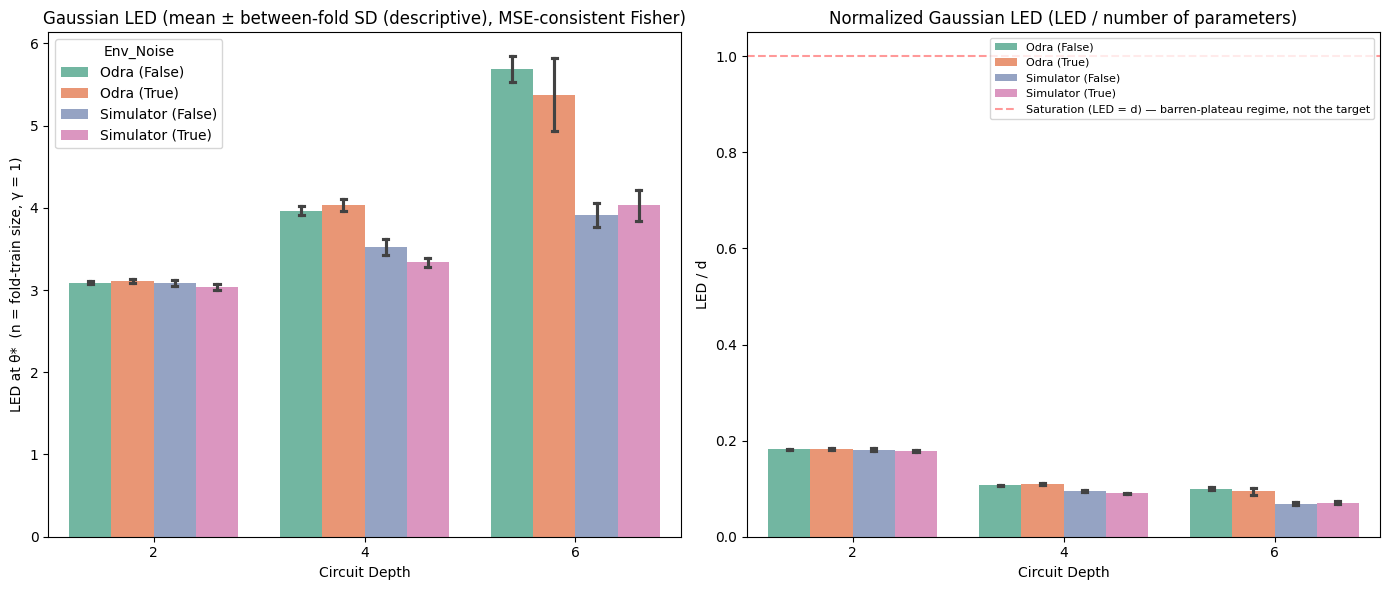


--- GAUSSIAN LOCAL EFFECTIVE DIMENSION (mean ± between-fold SD (descriptive)) ---
Environment  Depth  Noise  LED_mean  LED_std  Norm_mean  Norm_std  Folds
       Odra      2  False     3.091    0.021      0.182     0.001      5
       Odra      2   True     3.106    0.024      0.183     0.001      5
       Odra      4  False     3.966    0.054      0.107     0.001      5
       Odra      4   True     4.035    0.075      0.109     0.002      5
       Odra      6  False     5.686    0.156      0.100     0.003      5
       Odra      6   True     5.372    0.444      0.094     0.008      5
  Simulator      2  False     3.086    0.040      0.182     0.002      5
  Simulator      2   True     3.036    0.039      0.179     0.002      5
  Simulator      4  False     3.522    0.093      0.095     0.003      5
  Simulator      4   True     3.335    0.053      0.090     0.001      5
  Simulator      6  False     3.915    0.149      0.069     0.003      5
  Simulator      6   True     4.031    0.

In [18]:
RESULTS_CSV = "led_gauss_results.csv"
try:
    df_results
    if len(df_results) == 0:
        raise ValueError("empty in-memory results")
except (NameError, ValueError):
    df_results = pd.read_csv(RESULTS_CSV)
    print(f"Loaded {len(df_results)} rows from {RESULTS_CSV}")

agg = (
    df_results.groupby(["Environment", "Depth","Noise"])
    .agg(
        LED_mean=("LED", "mean"),
        LED_std=("LED", "std"),
        Norm_mean=("Normalized_LED", "mean"),
        Norm_std=("Normalized_LED", "std"),
        Folds=("LED", "count"),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(
    data=df_results,
    x="Depth",
    y="LED",
    hue="Env_Noise", 
    errorbar="sd",
    capsize=0.1,
    palette="Set2",
    ax=axes[0],
)
axes[0].set_title("Gaussian LED (mean ± between-fold SD (descriptive), MSE-consistent Fisher)")
axes[0].set_ylabel("LED at θ*  (n = fold-train size, γ = 1)")
axes[0].set_xlabel("Circuit Depth")

sns.barplot(
    data=df_results,
    x="Depth",
    y="Normalized_LED",
    hue="Env_Noise",
    errorbar="sd",
    capsize=0.1,
    palette="Set2",
    ax=axes[1],
)
axes[1].axhline(
    y=1.0,
    color="r",
    linestyle="--",
    alpha=0.4,
    label="Saturation (LED = d) — barren-plateau regime, not the target",
)
axes[1].set_title("Normalized Gaussian LED (LED / number of parameters)")
axes[1].set_ylabel("LED / d")
axes[1].set_xlabel("Circuit Depth")
axes[1].legend(fontsize=8, loc="upper right")

plt.tight_layout()
plt.show()

print("\n--- GAUSSIAN LOCAL EFFECTIVE DIMENSION (mean ± between-fold SD (descriptive)) ---")
print(agg.round(3).to_string(index=False))